In [1]:
import os
import sys
from pathlib import Path
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from attention import self_attention_torch, positional_encoding
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

TOKEN_TO_IDX = {"X": 0, "O": 1, "_": 2}
RESULT_TO_IDX = {"X": 1, "O": -1, "_": 0}  # for game result
X = "X"
O = "O"
EMPTY = "_"
cwd = Path().resolve().parent.parent

TRAINING_DATA_FILE_PATH = (
    "./data_generation_script/alphazero_puct_generated_data.json"
    #mcts_training_with_temperature_moves.json"
)


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")


In [2]:
device

device(type='cpu')

In [62]:
def load_training_data(file_path):
    if not os.path.exists(file_path):
        raise ValueError("File does not exists")
    with open(file_path, "r") as f:
        data = json.load(f)

    if not data:
        raise ValueError("No data")
    return data


In [63]:
training_data = load_training_data(TRAINING_DATA_FILE_PATH)

batch_zero = training_data[0]
batch_zero

[{'board': ['_', '_', '_', '_', '_', '_', '_', '_', '_'],
  'move': 3,
  'pi': [0.06532663316582915,
   0.18592964824120603,
   0.035175879396984924,
   0.21608040201005024,
   0.06532663316582915,
   0.21105527638190955,
   0.035175879396984924,
   0.1507537688442211,
   0.035175879396984924],
  'turn': 'X',
  'result': 'X'},
 {'board': ['_', '_', '_', 'X', '_', '_', '_', '_', '_'],
  'move': 0,
  'pi': [0.1457286432160804,
   0.23115577889447236,
   0.10050251256281408,
   0,
   0.010050251256281407,
   0.17587939698492464,
   0.08542713567839195,
   0.22110552763819097,
   0.03015075376884422],
  'turn': 'O',
  'result': 'X'},
 {'board': ['O', '_', '_', 'X', '_', '_', '_', '_', '_'],
  'move': 1,
  'pi': [0,
   0.1457286432160804,
   0.020100502512562814,
   0,
   0.10552763819095477,
   0.5728643216080402,
   0.020100502512562814,
   0.11055276381909548,
   0.02512562814070352],
  'turn': 'X',
  'result': 'X'},
 {'board': ['O', 'X', '_', 'X', '_', '_', '_', '_', '_'],
  'move': 6,


In [64]:
training_data[3]

[{'board': ['_', '_', '_', '_', '_', '_', '_', '_', '_'],
  'move': 3,
  'pi': [0.09547738693467336,
   0.18592964824120603,
   0.03015075376884422,
   0.271356783919598,
   0.06030150753768844,
   0.10552763819095477,
   0.06030150753768844,
   0.1507537688442211,
   0.04020100502512563],
  'turn': 'X',
  'result': 'O'},
 {'board': ['_', '_', '_', 'X', '_', '_', '_', '_', '_'],
  'move': 7,
  'pi': [0.12562814070351758,
   0.2562814070351759,
   0.10552763819095477,
   0,
   0.010050251256281407,
   0.1708542713567839,
   0.07537688442211055,
   0.21105527638190955,
   0.04522613065326633],
  'turn': 'O',
  'result': 'O'},
 {'board': ['_', '_', '_', 'X', '_', '_', '_', 'O', '_'],
  'move': 5,
  'pi': [0.12562814070351758,
   0.07537688442211055,
   0.02512562814070352,
   0,
   0.03015075376884422,
   0.6834170854271356,
   0.03015075376884422,
   0,
   0.03015075376884422],
  'turn': 'X',
  'result': 'O'},
 {'board': ['_', '_', '_', 'X', '_', 'X', '_', 'O', '_'],
  'move': 4,
  'pi':

# Data Preparation

- For training convert them to proper tensor
- Compute z from turn and result for each timestep: +1 if current player won, -1 if lost, 0 if draw.
- Convert all continuous values (pi, z) to float32 to match network output dtype.


In [65]:
for row in training_data:
    for col in row:
        col["board_indices"] = torch.tensor([TOKEN_TO_IDX[val] for val in col["board"]])
        col["result_index"] = torch.tensor(RESULT_TO_IDX[col["result"]])
        col["move"] = torch.tensor(col["move"])

        if col["result"] == col["turn"]:
            col["z"] = torch.tensor(1, dtype=torch.float32)
        elif col["result"] == EMPTY:
            col["z"] = torch.tensor(0, dtype=torch.float32)
        else:
            col["z"] = torch.tensor(-1, dtype=torch.float32)

        col["pi"] = torch.tensor(col["pi"], dtype=torch.float32)
        col["turn"] = torch.tensor(TOKEN_TO_IDX[col["turn"]])

In [66]:
flat_data = []
for game in training_data:
    for move in game:
        flat_data.append(move)

In [67]:
len(flat_data)

7344

In [68]:
# check entropy of training dataset to make sure the pi is suitable


In [69]:
class TTTDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

In [70]:
flat_data[0]

{'board': ['_', '_', '_', '_', '_', '_', '_', '_', '_'],
 'move': tensor(3),
 'pi': tensor([0.0653, 0.1859, 0.0352, 0.2161, 0.0653, 0.2111, 0.0352, 0.1508, 0.0352]),
 'turn': tensor(0),
 'result': 'X',
 'board_indices': tensor([2, 2, 2, 2, 2, 2, 2, 2, 2]),
 'result_index': tensor(1),
 'z': tensor(1.)}

In [71]:
spilt = int(0.8 * len(flat_data))
train_data = flat_data[:spilt]
val_data = flat_data[spilt:]
train_loader = DataLoader(TTTDataset(train_data), batch_size=1, shuffle=True)
val_loader = DataLoader(TTTDataset(val_data), batch_size=1, shuffle=False)

In [72]:
# uncertainity for moves in the given dataset
# meaning the policy loss for the model will never exceed below entropy
# to improve this need to increase the simulation times
# this is how much model should optimize its policy loss
epsilon = 1e-8
pi_lst = torch.stack([item["pi"] for item in flat_data])
entropy = -torch.sum(pi_lst * torch.log(pi_lst + epsilon), dim=1)
entropy.mean()

tensor(1.1431)

In [73]:
# worse possible value loss given by constant predictor
z = torch.stack([item["z"] for item in flat_data])
z_mean = z.mean()
baseline_value_loss = ((z - z_mean) ** 2).mean()
baseline_value_loss


tensor(0.7246)

In [74]:
# true learnable value loss
groups = defaultdict(list)
for item in flat_data:
    groups[tuple(item["board"])].append(item["z"])

avg_z = {board: torch.stack(z).mean() for board, z in groups.items()}
value_loss_floor = torch.cat(
    [(torch.stack(zs) - avg_z[board]) ** 2 for board, zs in groups.items()]
).mean()
value_loss_floor


tensor(0.2770)

In [76]:
len(groups)

1129

In [77]:
# taking small data sample for training so that the model overfits for the data
over_fit_data = [item for item in flat_data if max(item["pi"] > 0.8)]
over_fit_data = over_fit_data[:10]
over_fit_loader = DataLoader(TTTDataset(over_fit_data), batch_size=1, shuffle=True)

In [78]:
len(over_fit_data)

10

# Model Building


In [3]:
EMBEDDING_DIM = 16  # higher value for proper caputring of dim relationship
SEQ_LENGTH = 9  # board's state for a tic tac toe
VOCAB_SIZE = 3  # 3 possible board states: empty(_), X, O
FFN_HIDDEN_DIM = 32


class AlphaZeroTicTacToeTransformer(nn.Module):
    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.q_proj = nn.Linear(EMBEDDING_DIM, EMBEDDING_DIM, bias=False)
        self.k_proj = nn.Linear(EMBEDDING_DIM, EMBEDDING_DIM, bias=False)
        self.v_proj = nn.Linear(EMBEDDING_DIM, EMBEDDING_DIM, bias=False)
        self.embeddings = nn.Embedding(VOCAB_SIZE, EMBEDDING_DIM)

        self.ffn_linear1 = nn.Linear(EMBEDDING_DIM, FFN_HIDDEN_DIM)
        self.ffn_linear2 = nn.Linear(FFN_HIDDEN_DIM, EMBEDDING_DIM)

        # since softmax is shift-invariant and adding bias have no effect to the parameters
        self.policy_layer = nn.Linear(EMBEDDING_DIM, 1, bias=False)

        # flatten all 9 positions (9x16=144) into value_layer instead of mean-pooling, so piece signals aren't diluted by empty squares
        # also since tanh is shift-variant, and also first move advantage of X is captured by the bias so bias is required
        self.value_layer = nn.Linear(SEQ_LENGTH * EMBEDDING_DIM, 1)

    def forward(self, x: torch.Tensor):
        x = self.embeddings(x)
        x = x + positional_encoding(x).to(x.dtype)
        # outputs.shape = [seq_length X embed dim]
        # attn_weights.shape = [seq_length X seq_length]
        # outputs= updates embeddings, each pos carries relation info
        # attn_weights carries strength of relationships inbetween every pair pos
        q = self.q_proj(x)  # [9, 16]
        k = self.k_proj(x)
        v = self.v_proj(x)
        attn_out, attn_weights = self_attention_torch(q, k, v)

        # residual around attention
        x = x + attn_out

        hidden_layer = self.ffn_linear1(x)
        hidden_layer = torch.relu(hidden_layer)
        ffn_out = self.ffn_linear2(hidden_layer)

        # residual around FFN
        x = x + ffn_out

        # value head: winning prob given board state (-1 to +1)
        # all position embed_dim is taken into account, prev I was mean pooling which gave equal attention to empty spaces also(not optimal)
        value_pred = x.view(-1)
        value_pred = self.value_layer(value_pred)
        value_pred = torch.tanh(value_pred).squeeze(-1)

        # policy head: possible moves with prob, this is the outputlayer [SEQ_LEGNTH,]
        # return raw logits for now
        policy_logits = self.policy_layer(x)
        policy_log_probs = torch.log_softmax(policy_logits.squeeze(-1), dim=-1)

        # print("attn output shape", outputs.shape)
        # print("attn weights shape", attn_weights.shape)
        return (
            policy_log_probs,
            value_pred,
            attn_weights,
        )

# Generating Training Data

In [58]:
from data_generation_script.tic_tac_toe import Tictactoe

from data_generation_script.puct_mcts import PUCTNode
from copy import deepcopy
import random


def run_puct_vs_puct(
    model: AlphaZeroTicTacToeTransformer, simulations=10, temperature_moves=2
):
    game = Tictactoe()
    training_data = []
    count = 0
    while not game.is_gameover():
        count += 1
        root = PUCTNode(model=model, state=game)
        best_move = root.best_action(simulations_number=simulations, is_training=True)
        # calculate pie as
        # pi = root.visit_counts / sum (child.visit for child in root.children)
        total_visits = sum(child.visit_counts for child in root.children)

        pi = {
            child.parent_action: child.visit_counts / total_visits
            for child in root.children
        }

        pi_value: list[float] = [0] * 9
        for move, prob in pi.items():
            if move is not None:
                pi_value[move] = prob

        player_turn = root.player

        if count <= temperature_moves:
            best_move = random.choices(range(9), weights=pi_value)[0]
        else:
            best_move = pi_value.index(max(pi_value))

        training_data.append(
            {
                "board": deepcopy(game.board),
                "move": best_move,
                "pi": pi_value,
                "turn": player_turn,
            }
        )
        game.make_move(best_move)

    for entry in training_data:
        entry["result"] = game.winner
    return training_data, game.winner


def generate_training_data(
    model, filename=None, num_games=100, simulations=10, temperature_moves=2
):
    # 2d array each game are stored in batch wise
    all_data = []
    results = {"X": 0, "O": 0, "draw": 0}

    for _ in range(num_games):
        training_data, winner = run_puct_vs_puct(
            model, simulations, temperature_moves=temperature_moves
        )

        all_data.append(training_data)

        if winner in ["X", "O"]:
            results[winner] += 1
        else:
            results["draw"] += 1

    print(f"\ngame win summary {results}")
    if not filename:
        return

    with open(filename, "w") as f:
        json.dump(all_data, f)

    print(f"mcts training data saved {filename}")

In [ ]:
model = AlphaZeroTicTacToeTransformer()
model.load_state_dict(
    torch.load("alphazero_tictactoe_temperature_moves_with_mcts_best_action.pth")
)
model.eval()

SAVE_TRAINING_DATA = "./data_generation_script/alphazero_puct_generated_data.json"
#generate_training_data(model,SAVE_TRAINING_DATA,num_games=1000,simulations=200,temperature_moves=4)


game win summary {'X': 558, 'O': 222, 'draw': 220}
mcts training data saved ./data_generation_script/alphazero_puct_generated_data.json


In [80]:
initial_model = AlphaZeroTicTacToeTransformer()
x = torch.tensor([2, 2, 2, 2, 2, 2, 2, 2, 2])
p, v, w = initial_model(x)
p, v


(tensor([-1.8402, -1.6516, -1.6420, -1.9088, -2.3674, -2.8074, -3.0327, -3.0152,
         -2.8768], grad_fn=<LogSoftmaxBackward0>),
 tensor(0.7557, grad_fn=<SqueezeBackward1>))

In [81]:
model = AlphaZeroTicTacToeTransformer()
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
value_criterion = nn.MSELoss()

In [82]:
x = torch.tensor([1, 1, 2, 2, 2, 2, 2, 2, 2])
p, v, _ = model(x)
torch.exp(p), v

(tensor([0.0694, 0.0685, 0.0856, 0.1127, 0.1463, 0.1563, 0.1395, 0.1175, 0.1043],
        grad_fn=<ExpBackward0>),
 tensor(-0.1427, grad_fn=<SqueezeBackward1>))

In [83]:
def log_grad_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            norms[name] = param.grad.norm().item()
        else:
            norms[name] = 0.0  # no gradient reached this parameter at all
    return norms

In [84]:
# train_losses = []
# grad_history = []

# for epoch in range(500):
#     epoch_loss = 0.0
#     grads = None
#     for data in over_fit_loader:
#         x = data["board_indices"].squeeze(0).to(device)  # add batch dimension

#         z = data["z"].to(device)
#         pi = data["pi"].squeeze(0).to(device)

#         optimizer.zero_grad()
#         p, v, _ = model(x)
#         value_loss = value_criterion(v, z.squeeze())
#         policy_loss = -torch.sum(pi * p)

#         loss = value_loss + policy_loss

#         loss.backward()
#         grads = log_grad_norms(model)
#         optimizer.step()

#         epoch_loss += loss.item()  # accumulate batch loss

#     # These lines are **after the inner loop**, still inside epoch loop
#     avg_train_loss = epoch_loss / len(train_loader)
#     if grads is not None:
#         grad_history.append(grads)

#     train_losses.append(avg_train_loss)
#     model.train()

#     print(f"Epoch {epoch + 1} - Training Loss: {avg_train_loss:.4f}")

# Model Training

## Loss Function:

$$l = (z - v)^2 - \pi^\top \log p + c||\theta||^2$$


In [85]:
train_losses = []
val_losses = []
grad_history = []


for epoch in range(100):
    epoch_loss = 0.0
    grads = None
    epoch_policy_loss = 0.0
    epoch_value_loss = 0.0
    for data in train_loader:
        x = data["board_indices"].squeeze(0).to(device)  # add batch dimension

        z = data["z"].to(device)
        pi = data["pi"].squeeze(0).to(device)

        optimizer.zero_grad()
        p, v, _ = model(x)
        value_loss = value_criterion(v, z.squeeze())
        epoch_value_loss += value_loss.item()

        policy_loss = -torch.sum(pi * p)
        epoch_policy_loss += policy_loss.item()

        loss = value_loss + policy_loss

        loss.backward()
        grads = log_grad_norms(model)
        optimizer.step()

        epoch_loss += loss.item()  # accumulate batch loss

    # These lines are **after the inner loop**, still inside epoch loop
    avg_train_loss = epoch_loss / len(train_loader)
    avg_policy_loss = epoch_policy_loss / len(train_loader)
    avg_value_loss = epoch_value_loss / len(train_loader)
    if grads is not None:
        grad_history.append(grads)

    train_losses.append(avg_train_loss)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data in val_loader:
            x = data["board_indices"].squeeze(0).to(device)
            z = data["z"].to(device)
            pi = data["pi"].squeeze(0).to(device)
            p, v, _ = model(x)
            value_loss = value_criterion(v, z.squeeze())
            policy_loss = -torch.sum(pi * p)

            loss = value_loss + policy_loss
            val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
    model.train()

    print(
        f"Epoch {epoch + 1} - Training Loss: {avg_train_loss:.4f} Validation loss:{avg_val_loss:.4f} Value Loss: {avg_value_loss:.4f} Policy Loss: {avg_policy_loss:.4f}"
    )


Epoch 1 - Training Loss: 2.4731 Validation loss:2.2536 Value Loss: 0.7360 Policy Loss: 1.7371
Epoch 2 - Training Loss: 2.2715 Validation loss:2.2122 Value Loss: 0.6630 Policy Loss: 1.6085
Epoch 3 - Training Loss: 2.2534 Validation loss:2.1998 Value Loss: 0.6584 Policy Loss: 1.5950
Epoch 4 - Training Loss: 2.2410 Validation loss:2.1909 Value Loss: 0.6545 Policy Loss: 1.5866
Epoch 5 - Training Loss: 2.2320 Validation loss:2.1953 Value Loss: 0.6522 Policy Loss: 1.5797
Epoch 6 - Training Loss: 2.2266 Validation loss:2.1736 Value Loss: 0.6533 Policy Loss: 1.5732
Epoch 7 - Training Loss: 2.2187 Validation loss:2.1865 Value Loss: 0.6507 Policy Loss: 1.5680
Epoch 8 - Training Loss: 2.2111 Validation loss:2.1600 Value Loss: 0.6492 Policy Loss: 1.5619
Epoch 9 - Training Loss: 2.2014 Validation loss:2.1536 Value Loss: 0.6454 Policy Loss: 1.5560
Epoch 10 - Training Loss: 2.1964 Validation loss:2.1443 Value Loss: 0.6460 Policy Loss: 1.5504
Epoch 11 - Training Loss: 2.1872 Validation loss:2.1344 Val

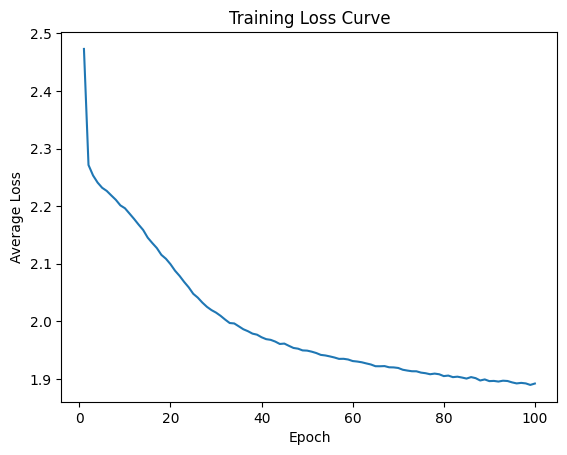

In [86]:
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve")
plt.show()


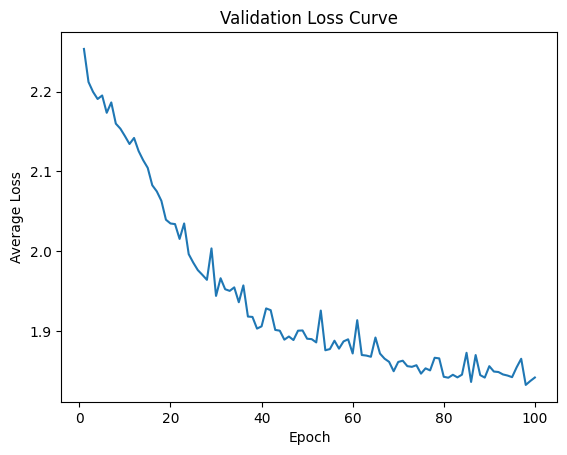

In [87]:
plt.plot(range(1, len(val_losses) + 1), val_losses)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Validation Loss Curve")
plt.show()

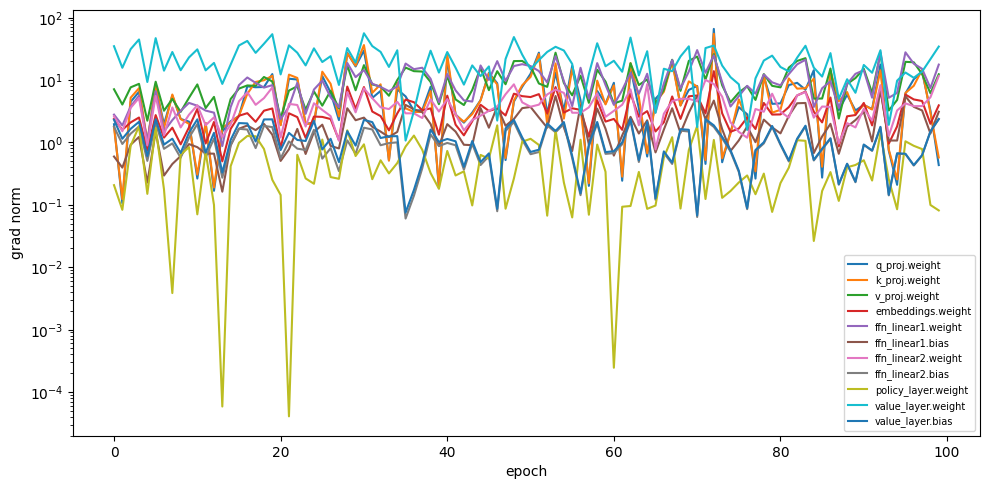

In [88]:
plt.figure(figsize=(10, 5))
for key in grad_history[0]:
    plt.plot([g[key] for g in grad_history], label=key)
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("grad norm")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# code for saving model
#torch.save(model.state_dict(), "alphazero_tictactoe_puct_model.pth")

# Model Evaluation


In [7]:
model = AlphaZeroTicTacToeTransformer()
model.load_state_dict(
    torch.load("alphazero_tictactoe_puct_model.pth")
)
model.eval()


def predict_move(model, board):
    indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])

    model.eval()
    with torch.no_grad():
        log_probs, value, attn_weights = model(indices)
        # print(log_probs)
    # mask illegal moves (non-empty cells)
    for i, cell in enumerate(board):
        if cell != "_":
            log_probs[i] = float("-inf")

    move = torch.argmax(log_probs).item()
    return move, value, attn_weights


def plot_board_attention(board, attn_weights, value):
    _, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax = axes[0]
    for i in range(3):
        for j in range(3):
            pos = i * 3 + j
            ax.text(
                j,
                2 - i,
                f"{board[pos]}\n({pos})",
                ha="center",
                va="center",
                fontsize=14,
            )
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 2.5)
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.grid(True)
    ax.set_title("Board")
    sns.heatmap(
        attn_weights.numpy(),
        annot=True,
        fmt=".2f",
        xticklabels=[f"{i}\n{board[i]}" for i in range(9)],
        yticklabels=[f"{i}\n{board[i]}" for i in range(9)],
        ax=axes[1],
    )
    axes[1].set_title(f"Attention | value={value.item():.3f}")
    plt.tight_layout()
    plt.show()


In [8]:
from data_generation_script.tic_tac_toe import Tictactoe
from data_generation_script.puct_mcts import PUCTNode

# 1. build a Tictactoe object matching your test board
game = Tictactoe()
game.board = ["X", "X", "_", "O", "O", "_", "_", "_", "_"]
game.turn = "X"  # whoever's turn it is in this test position

# 2. build the root node, passing your already-loaded model
root = PUCTNode(state=game, model=model)

# 3. run the search
best_move = root.best_action(simulations_number=1)
print(best_move)  # prediction: 2

2


In [ ]:
# O about to win - model should block at position 2
board = ["O", "O", "_", "X", "X", "_", "_", "_", "_"]
move, value, _ = predict_move(model, board)  # should return 2 or 5
print(move, value)

# X about to win - model should play position 2
board = ["X", "X", "_", "O", "O", "_", "_", "_", "_"]
move, value, _ = predict_move(model, board)  # should return 2
root = PUCTNode(state=board, model=model)
print(move)

In [ ]:
flat_data[0]

In [ ]:
for game in flat_data[:10]:
    ai_move, _, _ = predict_move(model, game["board"])
    mcts_best = game["pi"].argmax().item()
    print(
        f"ai_agent move: {ai_move} ,mcts_best move : {mcts_best} {ai_move == mcts_best}"
    )


In [ ]:
training_data[0]

In [ ]:
game_signatures = set()
for game in training_data:  # the 2D list, before flattening
    signature = tuple(item["move"].item() for item in game)
    game_signatures.add(signature)
print(len(game_signatures), "unique games out of", len(training_data))

In [ ]:
boards = {
    "empty": ["_", "_", "_", "_", "_", "_", "_", "_", "_"],
    "X about to win": ["X", "X", "_", "O", "O", "_", "_", "_", "_"],
    "midgame": ["X", "O", "_", "_", "X", "O", "_", "_", "_"],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, board) in zip(axes, boards.items()):
    indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])
    model.eval()
    with torch.no_grad():
        logits, weights = model(indices)

    weight_matrix = weights
    cell_labels = [f"{s} ({i})" for i, s in enumerate(board)]

    im = ax.imshow(weight_matrix, cmap="hot")
    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
    ax.set_xticklabels(cell_labels, fontsize=8)
    ax.set_yticklabels(cell_labels, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [4]:
mcts_trained_model = AlphaZeroTicTacToeTransformer()
mcts_trained_model.load_state_dict(
    torch.load("alphazero_tictactoe_temperature_moves_with_mcts_best_action.pth")
)
mcts_trained_model.eval()

AlphaZeroTicTacToeTransformer(
  (q_proj): Linear(in_features=16, out_features=16, bias=False)
  (k_proj): Linear(in_features=16, out_features=16, bias=False)
  (v_proj): Linear(in_features=16, out_features=16, bias=False)
  (embeddings): Embedding(3, 16)
  (ffn_linear1): Linear(in_features=16, out_features=32, bias=True)
  (ffn_linear2): Linear(in_features=32, out_features=16, bias=True)
  (policy_layer): Linear(in_features=16, out_features=1, bias=False)
  (value_layer): Linear(in_features=144, out_features=1, bias=True)
)

In [21]:
import random
from data_generation_script.uct_mcts import MCTSNode
from data_generation_script.tic_tac_toe import Tictactoe
from copy import deepcopy


mcts_agent = X
ai_agent = O

print(f"mcts_agent: {mcts_agent} and ai_agent:{ai_agent}")
results = {"X": 0, "O": 0, "draw": 0}
for _ in range(100):
    game = Tictactoe()
    while not game.is_gameover():
        if game.turn == ai_agent:
            root = PUCTNode(state=game, model=model)

            best_move = root.best_action(simulations_number=100,is_training=True)

            # print("game board",game.board)
            # best_move,_,_ = predict_move(model, game.board)
            print("ai agent move", best_move)

            game.make_move(best_move)
        else:
            root = MCTSNode(state=game)
            best_move = root.best_action(simulations_number=1)
            # print("===mcts best move===", mcts_best_move)
            # root = PUCTNode(state=game, model=mcts_trained_model)
            # best_move = root.best_action(simulations_number=1,is_training=True)
            print("best ai mcts_trained_model move", best_move)
            game.make_move(best_move)

    game.print_board()
    print("\n\n")

    if game.winner == game.X:
        results["X"] += 1
        # print("X won!")
    elif game.winner == game.O:
        results["O"] += 1
        # print("O won!")
    else:
        results["draw"] += 1
        # print("Draw!")

mcts_agent: X and ai_agent:O
best ai mcts_trained_model move 8
ai agent move 7
best ai mcts_trained_model move 6
ai agent move 1
best ai mcts_trained_model move 5
ai agent move 4
_|O|_
_|O|X
X|O|X



best ai mcts_trained_model move 8
ai agent move 7
best ai mcts_trained_model move 6
ai agent move 5
best ai mcts_trained_model move 4
ai agent move 0
best ai mcts_trained_model move 3
ai agent move 2
best ai mcts_trained_model move 1
O|X|O
X|X|O
X|O|X



best ai mcts_trained_model move 8
ai agent move 7
best ai mcts_trained_model move 6
ai agent move 1
best ai mcts_trained_model move 5
ai agent move 4
_|O|_
_|O|X
X|O|X



best ai mcts_trained_model move 8
ai agent move 7
best ai mcts_trained_model move 6
ai agent move 1
best ai mcts_trained_model move 5
ai agent move 4
_|O|_
_|O|X
X|O|X



best ai mcts_trained_model move 8
ai agent move 7
best ai mcts_trained_model move 6
ai agent move 1
best ai mcts_trained_model move 5
ai agent move 4
_|O|_
_|O|X
X|O|X



best ai mcts_trained_model move 

In [22]:
print(f"mcts_agent: {mcts_agent} and ai_agent:{ai_agent}")
results

mcts_agent: X and ai_agent:O


{'X': 0, 'O': 91, 'draw': 9}

In [ ]:
#predict_move(model, ["X","X","_","O","O","_","_","_","_"])
predict_move(model, ["O","O","_","X","X","_","_","_","_"])

In [ ]:
torch.save(model.state_dict(), "tictactoe_transformer_model.pth")

In [ ]:
target_board = ["O", "O", "_", "X", "X", "_", "_", "_", "_"]
for game in training_data:
    for move in game:
        if move["board"] == target_board:
            print(move["pi"])

In [ ]:
print(predict_move(model, ["O", "X", "_", "_", "_", "X", "O", "_", "_"]))

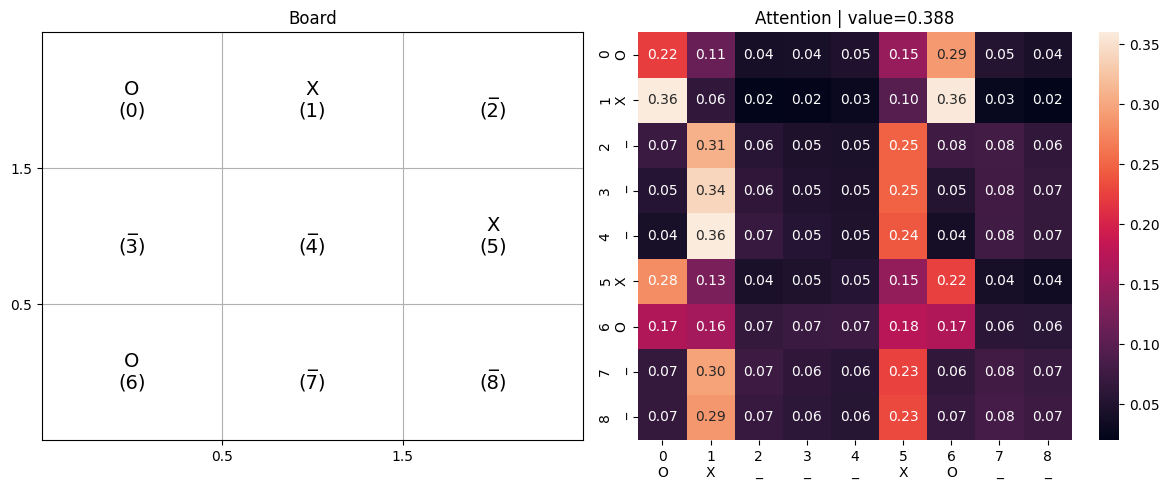

In [98]:
board = ["O", "X", "_", "_", "_", "X", "O", "_", "_"]
move, value, attn_weights = predict_move(model=model, board=board)
plot_board_attention(board, attn_weights, value)

In [100]:
empty_board = ["_", "_", "_", "_", "_", "_", "_", "_", "_"]
x_close_win_board = ["X", "X", "_", "_", "_", "_", "_", "_", "_"]
mirrored_of_x_close_win_board = ["_", "X", "X", "_", "_", "_", "_", "_", "_"]


In [ ]:
board = ["O", "X", "_", "_", "_", "X", "O", "_", "_"]
indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])

with torch.no_grad():
    log_probs, value, attn_weights = model(indices)

In [ ]:
value

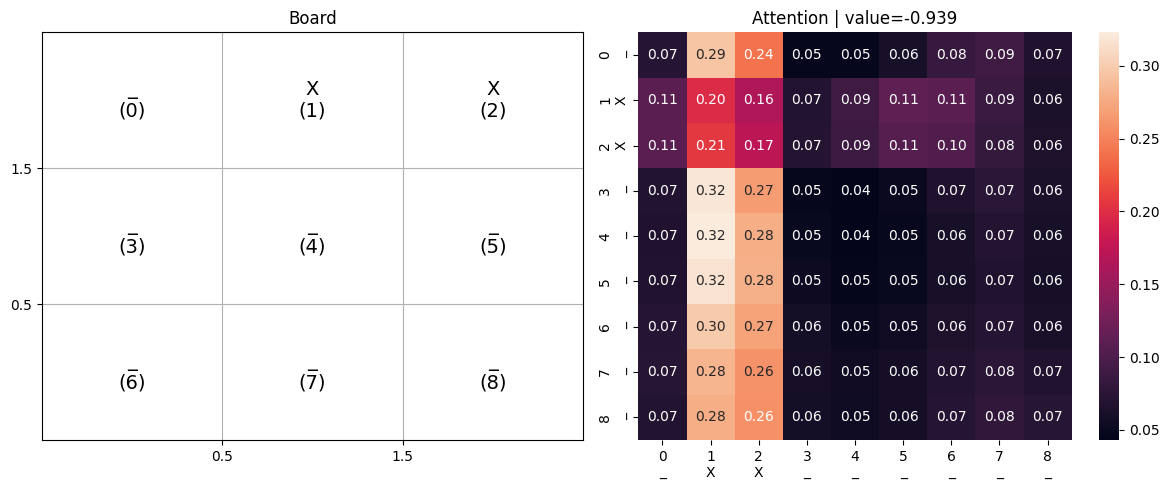

In [101]:
move, value, attn_weights = predict_move(
    model=model, board=mirrored_of_x_close_win_board
)
plot_board_attention(mirrored_of_x_close_win_board, attn_weights, value)

In [ ]:
move, value, attn_weights = predict_move(model=model, board=x_close_win_board)
plot_board_attention(x_close_win_board, attn_weights, value)

In [ ]:
move, value, attn_weights = predict_move(model=model, board=empty_board)

In [ ]:
board = ["X", "X", "_", "O", "O", "_", "_", "_", "_"]

test_move,value,attn_weights = predict_move(model,board=board)
plot_board_attention(board,attn_weights,value)
print(test_move)

In [ ]:
plot_board_attention(empty_board, attn_weights, value)

In [ ]:
value

In [ ]:
_, value, attn_weights = predict_move(model=model, board=x_close_win_board)
plot_board_attention(x_close_win_board, attn_weights, value)